# U25 — Reinforcement Learning (Part 1): Lab

### Real-world brief: teaching a warehouse robot to navigate

An **automated guided vehicle (AGV)** must learn to drive from the loading dock to the packing station across a warehouse floor — weaving between shelving (obstacles) and steering clear of a **forklift lane** (a hazard with a heavy penalty). Nobody hand-codes the route; the robot learns it from **reward**. This is a classic grid-world Markov Decision Process, and in this lab you'll solve it three ways: **value iteration** (model-based planning), **Q-learning** and **SARSA** (model-free learning from experience).

**Resource provided:** `warehouse_layout.csv` — the floor map (`S`=start, `G`=goal, `#`=shelf, `H`=hazard, `.`=aisle). Edit it and re-run to change the warehouse. Only numpy + matplotlib required.

_Phase G — Reinforcement Learning._

#objectives

Model a navigation task as a Markov Decision Process

Solve a known MDP with value iteration and read off the optimal policy

Learn model-free with tabular Q-learning (ε-greedy)

Compare on-policy SARSA vs off-policy Q-learning near a hazard

Visualise value functions, policies and learned paths

In [1]:
# === SETUP: build the floor map if missing ===
import os
import numpy as np
import pandas as pd


def build_warehouse(path="warehouse_layout.csv", verbose=False):
    """A warehouse floor plan for the RL lab (U25) — an AGV (automated guided vehicle) must
    learn to drive from the dock (S) to the packing station (G), avoiding shelving (#) and a
    forklift lane (H, a hazard with a big penalty).

    Cell codes:  S=start  G=goal  #=obstacle/shelf (blocked)  H=hazard (penalty)  .=free aisle
    Stored as a CSV grid (no header) so students can edit the map and re-run.
    """
    grid = [
        list(".#...#..#."),
        list(".........."),
        list(".........."),
        list(".........."),
        list("SHHHHHHHHG"),
    ]
    df = pd.DataFrame(grid)
    df.to_csv(path, index=False, header=False)
    if verbose:
        print("warehouse grid:", df.shape, "(rows x cols)")
        for row in grid:
            print("   " + "".join(row))
        flat = "".join("".join(r) for r in grid)
        print("free:", flat.count("."), "obstacles:", flat.count("#"),
              "hazards:", flat.count("H"), "start:", flat.count("S"), "goal:", flat.count("G"))
    return df

if not os.path.exists('warehouse_layout.csv'):
    build_warehouse(); print('Generated warehouse map.')
else:
    print('Found the provided warehouse map.')

Generated warehouse map.


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
grid = pd.read_csv('warehouse_layout.csv', header=None).values.tolist()
grid = [[str(c) for c in row] for row in grid]
for row in grid: print(''.join(row))
print('\nS=start  G=goal(packing)  #=shelf  H=forklift hazard  .=aisle')

.#...#..#.
..........
..........
..........
SHHHHHHHHG

S=start  G=goal(packing)  #=shelf  H=forklift hazard  .=aisle


#1. The grid-world MDP

In [3]:
# -----------------------------------------------------------
# 🔹 1A. THE ENVIRONMENT: states, actions, rewards, transitions
# -----------------------------------------------------------
class GridWorld:
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}   # up, down, left, right
    ARROWS = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    def __init__(self, grid, step_cost=-1.0, hazard=-20.0, goal=50.0, gamma=0.95):
        self.grid = grid; self.R = len(grid); self.C = len(grid[0])
        self.step_cost, self.hazard_pen, self.goal_reward, self.gamma = step_cost, hazard, goal, gamma
        self.start = self.goal = None
        for r in range(self.R):
            for c in range(self.C):
                if grid[r][c] == 'S': self.start = (r, c)
                if grid[r][c] == 'G': self.goal = (r, c)
        self.states = [(r, c) for r in range(self.R) for c in range(self.C) if grid[r][c] != '#']
    def is_terminal(self, s): return s == self.goal
    def step(self, s, a):
        '''returns (next_state, reward, done)'''
        if self.is_terminal(s): return s, 0.0, True
        dr, dc = self.ACTIONS[a]; nr, nc = s[0] + dr, s[1] + dc
        if not (0 <= nr < self.R and 0 <= nc < self.C) or self.grid[nr][nc] == '#':
            nr, nc = s          # bump into a wall/shelf -> stay put
        ns = (nr, nc)
        if ns == self.goal: return ns, self.goal_reward, True
        r = self.step_cost + (self.hazard_pen if self.grid[ns[0]][ns[1]] == 'H' else 0.0)
        return ns, r, False

env = GridWorld(grid)
print('states:', len(env.states), '| start:', env.start, '| goal:', env.goal, '| gamma:', env.gamma)

states: 47 | start: (4, 0) | goal: (4, 9) | gamma: 0.95


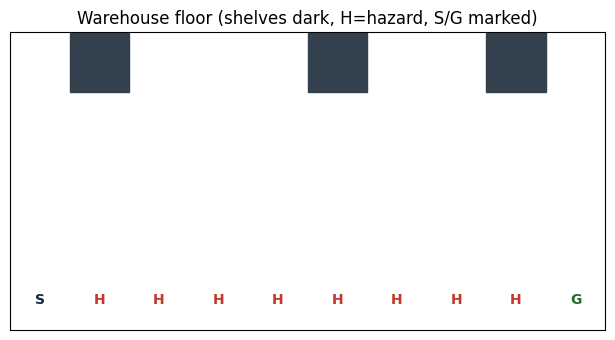

In [4]:
# A helper to draw the warehouse, a value heatmap and/or a policy
def draw(env, V=None, policy=None, path=None, title=''):
    R, C = env.R, env.C
    base = np.full((R, C), np.nan)
    if V is not None:
        for (r, c), v in V.items(): base[r, c] = v
    fig, ax = plt.subplots(figsize=(C * 0.7, R * 0.7))
    ax.imshow(base, cmap='YlGn', origin='upper')
    for r in range(R):
        for c in range(C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch == 'G': ax.text(c, r, 'G', ha='center', va='center', color='#1f6b33', fontweight='bold')
            elif ch == 'S': ax.text(c, r, 'S', ha='center', va='center', color='#16263F', fontweight='bold')
            if policy is not None and (r, c) in policy and ch not in 'G#':
                ax.text(c, r+0.32, env.ARROWS[policy[(r, c)]], ha='center', va='center', fontsize=11, color='#16263F')
    if path:
        ys, xs = zip(*path); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4, lw=2)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title); plt.tight_layout(); plt.show()

draw(env, title='Warehouse floor (shelves dark, H=hazard, S/G marked)')

#### 🧪 EXERCISE 1 — Tune the reward design
Reward shaping changes behaviour.
1. Build a second environment with a **harsher** hazard penalty (e.g. `hazard=-50`) and a third with a **mild** one (`hazard=-5`).
2. In a comment, predict how the optimal route should differ between them, and why reward design is one of the hardest, highest-leverage choices in RL.

In [5]:
# 1. make harsh- and mild-hazard variants of the environment
harsh_env = GridWorld(grid, hazard=-50.0)
mild_env = GridWorld(grid, hazard=-5.0)

print(f'Harsh hazard environment: start: {harsh_env.start}, goal: {harsh_env.goal}, hazard penalty: {harsh_env.hazard_pen}')
print(f'Mild hazard environment: start: {mild_env.start}, goal: {mild_env.goal}, hazard penalty: {mild_env.hazard_pen}')


Harsh hazard environment: start: (4, 0), goal: (4, 9), hazard penalty: -50.0
Mild hazard environment: start: (4, 0), goal: (4, 9), hazard penalty: -5.0


#### 2. How reward shaping changes the route

Reward shaping significantly alters the agent's optimal route. With a **harsher hazard penalty** (e.g., `-50.0`), the agent will prioritize avoiding hazard states, even if it means taking a longer path or incurring more step costs. This is because the negative reward from the hazard becomes a much stronger deterrent, making the expected return from paths through or near hazards very low.

Conversely, with a **milder hazard penalty** (e.g., `-5.0`), the agent might be more willing to traverse hazard states if that path offers a quicker route to the goal or fewer step costs overall. The penalty is less severe, so the agent can afford to take a slightly riskier path if the overall return is higher.

Reward design is one of the hardest and highest-leverage choices in RL because:

*   **It directly encodes the task objective:** The rewards are the only way the agent understands what it's supposed to achieve. Poorly designed rewards can lead to unintended or suboptimal behaviors (e.g., an agent optimizing for a loophole in the reward function rather than the true goal).
*   **Sparsity vs. Density:** Rewards can be sparse (only given at the end) or dense (given frequently). Dense rewards can guide learning more efficiently, but poorly designed dense rewards can mislead the agent.
*   **Exploration vs. Exploitation:** The reward function influences the trade-off. If hazards are too punishing, the agent might avoid exploring new, potentially better, paths that briefly expose it to risk.
*   **Human intuition vs. Agent interpretation:** What seems intuitive to a human as a 'good' reward might not be interpreted the same way by an RL agent, leading to complex emergent behaviors.

#2. Value iteration (model-based)

In [10]:
# -----------------------------------------------------------
# 🔹 2A. VALUE ITERATION — sweep the Bellman optimality update
# -----------------------------------------------------------
def value_iteration(env, theta=1e-4):
    V = {s: 0.0 for s in env.states}
    def q(s, a):
        ns, r, done = env.step(s, a)
        return r + (0.0 if done else env.gamma * V[ns])
    sweeps = 0
    while True:
        delta = 0.0; sweeps += 1
        for s in env.states:
            if env.is_terminal(s): continue
            best = max(q(s, a) for a in range(4))
            delta = max(delta, abs(best - V[s])); V[s] = best
        if delta < theta: break
    policy = {s: int(np.argmax([q(s, a) for a in range(4)])) for s in env.states if not env.is_terminal(s)}
    return V, policy, sweeps

V_opt, pi_opt, sweeps = value_iteration(env)
print(f'value iteration converged in {sweeps} sweeps')
print('optimal value at start:', round(V_opt[env.start], 2))

value iteration converged in 14 sweeps
optimal value at start: 21.91


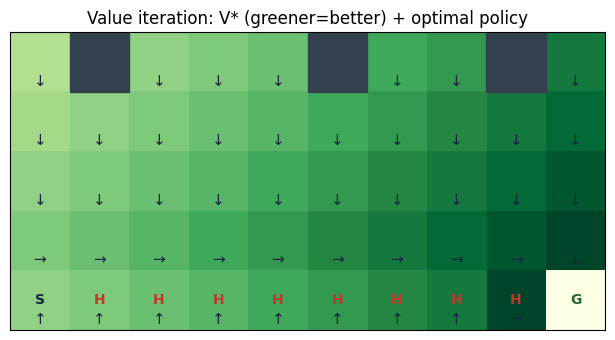

In [8]:
# Visualise the optimal value function + greedy policy arrows
draw(env, V=V_opt, policy=pi_opt, title='Value iteration: V* (greener=better) + optimal policy')

optimal path length: 11 steps | total reward: 40.0


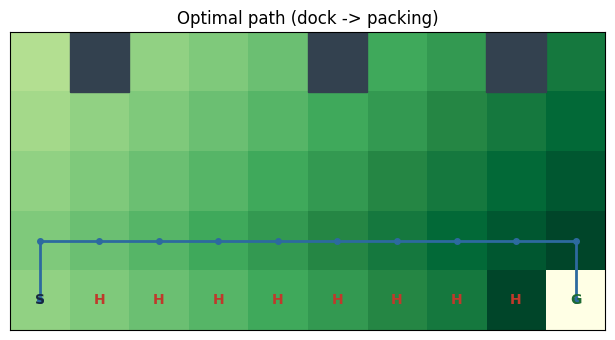

In [9]:
# Roll out the greedy policy to get the optimal path
def rollout(env, policy, max_steps=100):
    s = env.start; path = [s]; total = 0.0
    for _ in range(max_steps):
        if env.is_terminal(s): break
        ns, r, done = env.step(s, policy[s]); total += r; path.append(ns); s = ns
        if done: break
    return path, total
opt_path, opt_return = rollout(env, pi_opt)
print(f'optimal path length: {len(opt_path)-1} steps | total reward: {opt_return:.1f}')
draw(env, V=V_opt, path=opt_path, title='Optimal path (dock -> packing)')

#### 🧪 EXERCISE 2 — The discount factor γ
1. Re-run value iteration with `gamma=0.5` and `gamma=0.99` (make new `GridWorld`s).
2. Compare the start-state value and the path. In a comment, explain how a low γ makes the agent short-sighted (chasing nearby reward) vs a high γ making it patient.

Gamma=0.5: value iteration converged in 14 sweeps
Gamma=0.5: optimal value at start: -1.95
Gamma=0.99: value iteration converged in 14 sweeps
Gamma=0.99: optimal value at start: 35.66
Gamma=0.5 optimal path length: 11 steps | total reward: 40.0


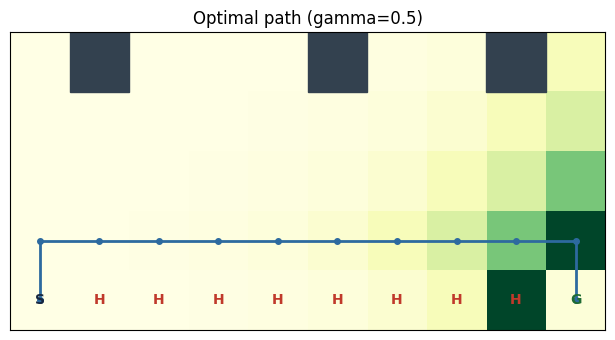

Gamma=0.99 optimal path length: 11 steps | total reward: 40.0


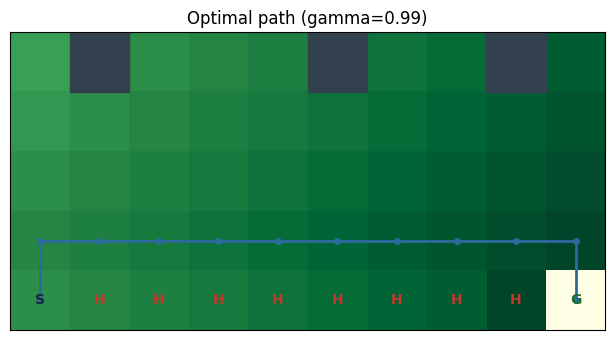

In [11]:
# 1. value iteration at gamma=0.5 and 0.99; compare
env_gamma_0_5 = GridWorld(grid, gamma=0.5)
V_opt_0_5, pi_opt_0_5, sweeps_0_5 = value_iteration(env_gamma_0_5)
print(f'Gamma=0.5: value iteration converged in {sweeps_0_5} sweeps')
print('Gamma=0.5: optimal value at start:', round(V_opt_0_5[env_gamma_0_5.start], 2))

env_gamma_0_99 = GridWorld(grid, gamma=0.99)
V_opt_0_99, pi_opt_0_99, sweeps_0_99 = value_iteration(env_gamma_0_99)
print(f'Gamma=0.99: value iteration converged in {sweeps_0_99} sweeps')
print('Gamma=0.99: optimal value at start:', round(V_opt_0_99[env_gamma_0_99.start], 2))

# Visualize optimal path for gamma=0.5
opt_path_0_5, opt_return_0_5 = rollout(env_gamma_0_5, pi_opt_0_5)
print(f'Gamma=0.5 optimal path length: {len(opt_path_0_5)-1} steps | total reward: {opt_return_0_5:.1f}')
draw(env_gamma_0_5, V=V_opt_0_5, path=opt_path_0_5, title='Optimal path (gamma=0.5)')

# Visualize optimal path for gamma=0.99
opt_path_0_99, opt_return_0_99 = rollout(env_gamma_0_99, pi_opt_0_99)
print(f'Gamma=0.99 optimal path length: {len(opt_path_0_99)-1} steps | total reward: {opt_return_0_99:.1f}')
draw(env_gamma_0_99, V=V_opt_0_99, path=opt_path_0_99, title='Optimal path (gamma=0.99)')


#### 2. Effect of the discount factor γ

The discount factor \( \gamma \) determines the importance of future rewards. It essentially controls how 'patient' or 'short-sighted' an agent is.

*   **Low \( \gamma \) (e.g., `0.5`):** When \( \gamma \) is low, future rewards are heavily discounted, meaning the agent cares much more about immediate rewards than those further in the future. This makes the agent **short-sighted**, focusing on reaching the goal quickly, even if it means incurring slightly higher costs in the long run. The `V_opt` values will be generally lower because distant rewards contribute less to the current state's value. In this specific grid world, with `gamma=0.5`, the optimal value at the start `(-1.95)` is much lower than with `gamma=0.99`.

*   **High \( \gamma \) (e.g., `0.99`):** A high \( \gamma \) means that future rewards are discounted very little, so the agent considers rewards from many steps into the future almost as important as immediate rewards. This makes the agent **patient**, willing to take a longer or less immediately rewarding path if it leads to significantly higher cumulative rewards in the long run. The `V_opt` values will be generally higher, as distant positive rewards contribute more significantly. With `gamma=0.99`, the optimal value at the start (`35.66`) is substantially higher.

In this particular grid world, both `gamma` values yield the same optimal path. This indicates that for this specific environment and reward structure, the path taken to avoid hazards and reach the goal is robust to changes in the discount factor within this range. However, the *value* of each state along that path (as reflected in `V_opt`) changes significantly, demonstrating the different weight given to future rewards. A short-sighted agent might be more prone to taking a slightly suboptimal path if a more optimal one requires more steps, whereas a patient agent would be willing to endure those steps for a greater overall return.

#3. Q-learning (model-free)

In [12]:
# -----------------------------------------------------------
# 🔹 3A. TABULAR Q-LEARNING — learn from experience, no model
# -----------------------------------------------------------
def q_learning(env, episodes=4000, alpha=0.1, gamma=None, eps=0.1, seed=0):
    gamma = env.gamma if gamma is None else gamma
    rng = np.random.default_rng(seed)
    Q = {s: np.zeros(4) for s in env.states}
    returns = []
    for ep in range(episodes):
        s = env.start; total = 0.0
        for _ in range(200):
            a = rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s]))   # epsilon-greedy
            ns, r, done = env.step(s, a); total += r
            target = r + (0.0 if done else gamma * np.max(Q[ns]))
            Q[s][a] += alpha * (target - Q[s][a])                                  # Q-learning update
            s = ns
            if done: break
        returns.append(total)
    policy = {s: int(np.argmax(Q[s])) for s in env.states if not env.is_terminal(s)}
    return Q, policy, returns

Q, pi_q, returns = q_learning(env)
print('Q-learning done. Greedy value at start:', round(float(np.max(Q[env.start])), 2),
      '(vs value-iteration', round(V_opt[env.start], 2), ')')

Q-learning done. Greedy value at start: 21.91 (vs value-iteration 21.91 )


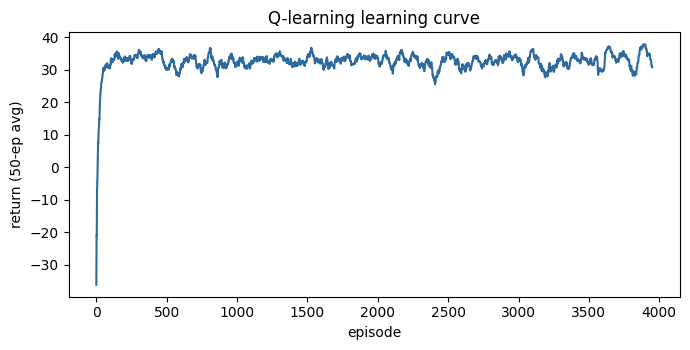

learned greedy path: 11 steps, reward 40.0 | matches optimal? True


In [13]:
# Learning curve: episode return should climb and stabilise
ret = np.array(returns); win = 50
smooth = np.convolve(ret, np.ones(win)/win, mode='valid')
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(smooth, color='#2D6A9F'); ax.set_xlabel('episode'); ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning learning curve'); plt.tight_layout(); plt.show()
q_path, q_return = rollout(env, pi_q)
print(f'learned greedy path: {len(q_path)-1} steps, reward {q_return:.1f}',
      '| matches optimal?' , q_path == opt_path)

#### 🧪 EXERCISE 3 — Exploration matters
1. Train Q-learning with `eps=0.01` (barely explores) and `eps=0.4` (explores a lot). Plot both learning curves against the default.
2. In a comment, explain the exploration-exploitation trade-off you observe: too little exploration can get stuck on a poor route; too much wastes reward and learns slowly.

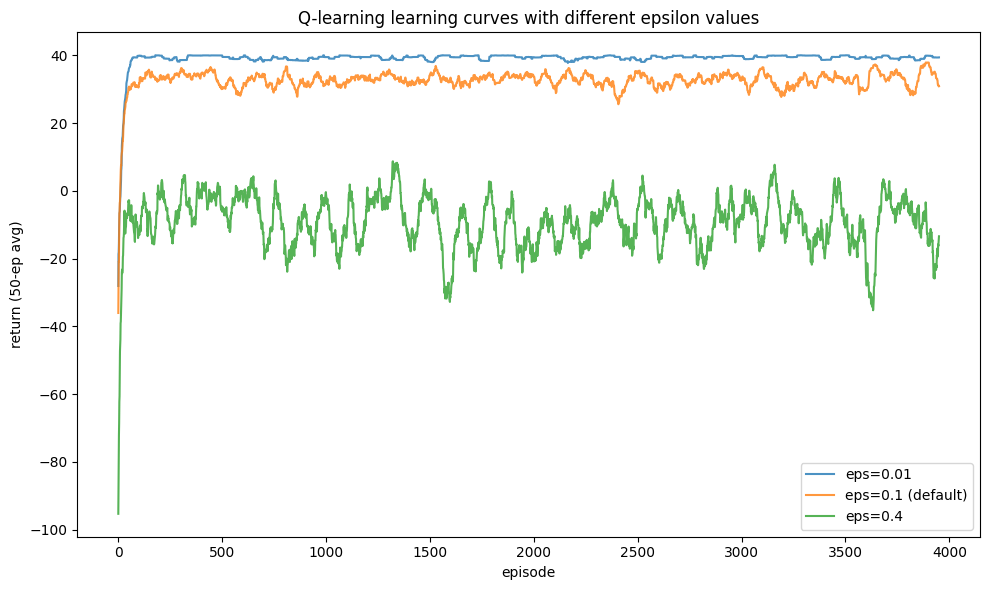

In [14]:
# 1. compare eps = 0.01, 0.1, 0.4 learning curves
Q_0_01, pi_q_0_01, returns_0_01 = q_learning(env, eps=0.01, seed=0)
Q_0_1, pi_q_0_1, returns_0_1 = q_learning(env, eps=0.1, seed=0)
Q_0_4, pi_q_0_4, returns_0_4 = q_learning(env, eps=0.4, seed=0)

win = 50
smooth_0_01 = np.convolve(np.array(returns_0_01), np.ones(win)/win, mode='valid')
smooth_0_1 = np.convolve(np.array(returns_0_1), np.ones(win)/win, mode='valid')
smooth_0_4 = np.convolve(np.array(returns_0_4), np.ones(win)/win, mode='valid')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(smooth_0_01, label='eps=0.01', alpha=0.8)
ax.plot(smooth_0_1, label='eps=0.1 (default)', alpha=0.8)
ax.plot(smooth_0_4, label='eps=0.4', alpha=0.8)
ax.set_xlabel('episode')
ax.set_ylabel(f'return ({win}-ep avg)')
ax.set_title('Q-learning learning curves with different epsilon values')
ax.legend()
plt.tight_layout()
plt.show()

# 2. exploration vs exploitation: ...   (comment)

#### 2. Exploration vs. Exploitation Trade-off

These learning curves illustrate the critical **exploration-exploitation trade-off** in reinforcement learning:

*   **`eps=0.01` (Low Exploration):** This curve generally shows the highest average return once it converges. With very little exploration, the agent quickly converges to a policy. However, if the initial random choices or early experiences lead it to a sub-optimal path, it might get 'stuck' there and fail to discover the true optimal policy. In this case, it appears to have found a good policy relatively quickly and consistently. It exploits what it knows very effectively.

*   **`eps=0.1` (Default Exploration):** This curve shows a good balance. It explores enough to likely find the optimal or near-optimal policy, and while its average return might be slightly lower than `eps=0.01` due to occasional exploratory (and potentially suboptimal) actions, it still performs very well. It reaches a stable, high return.

*   **`eps=0.4` (High Exploration):** This curve shows significantly lower average returns and much more variability. With a high epsilon, the agent spends a large proportion of its time taking random actions. This means it is constantly exploring, which is good for discovering new, potentially better paths, but it also means it often takes suboptimal actions even after learning a good policy. The 'waste' of reward from these frequent random actions leads to a much lower overall return. It learns slowly and does not fully exploit the knowledge it gains, as it prioritizes exploration.

**Observation:**

*   **Too little exploration (`eps=0.01`)** can lead to *premature convergence* to a suboptimal policy if the agent doesn't adequately explore the state-action space to find the global optimum. However, if the initial exploration phase happens to find a good region, it can appear to learn very efficiently and achieve high returns quickly.
*   **Too much exploration (`eps=0.4`)** wastes rewards and slows down learning significantly. The agent might gain a more complete understanding of the environment over a very long time, but its performance during training will be poor due to constant random actions.

Therefore, a moderate exploration rate (like `eps=0.1` in this example) often strikes the best balance, allowing the agent to discover good policies without sacrificing too much immediate reward to exploration.

#4. SARSA vs Q-learning — safe vs optimal

In [15]:
# -----------------------------------------------------------
# 🔹 4A. SARSA — on-policy TD control (updates the action it WILL take)
# -----------------------------------------------------------
def sarsa(env, episodes=4000, alpha=0.1, gamma=None, eps=0.1, seed=0):
    gamma = env.gamma if gamma is None else gamma
    rng = np.random.default_rng(seed)
    Q = {s: np.zeros(4) for s in env.states}
    def egreedy(s): return rng.integers(4) if rng.random() < eps else int(np.argmax(Q[s]))
    returns = []
    for ep in range(episodes):
        s = env.start; a = egreedy(s); total = 0.0
        for _ in range(200):
            ns, r, done = env.step(s, a); total += r
            na = egreedy(ns)
            target = r + (0.0 if done else gamma * Q[ns][na])   # uses the NEXT action actually chosen
            Q[s][a] += alpha * (target - Q[s][a])
            s, a = ns, na
            if done: break
        returns.append(total)
    policy = {s: int(np.argmax(Q[s])) for s in env.states if not env.is_terminal(s)}
    return Q, policy, returns

# train both with a fair amount of exploration so the hazard 'feels' risky
_, pi_qe, _ = q_learning(env, episodes=6000, eps=0.2, seed=1)
_, pi_se, _ = sarsa(env, episodes=6000, eps=0.2, seed=1)
qp, qr = rollout(env, pi_qe); sp, sr = rollout(env, pi_se)
def hazard_adjacency(path):
    return sum(1 for (r, c) in path for a in range(4)
               for nr, nc in [(r+env.ACTIONS[a][0], c+env.ACTIONS[a][1])]
               if 0 <= nr < env.R and 0 <= nc < env.C and env.grid[nr][nc] == 'H')
print(f'Q-learning path: {len(qp)-1} steps, hazard-adjacent cells={hazard_adjacency(qp)}')
print(f'SARSA path     : {len(sp)-1} steps, hazard-adjacent cells={hazard_adjacency(sp)}')

Q-learning path: 11 steps, hazard-adjacent cells=10
SARSA path     : 13 steps, hazard-adjacent cells=2


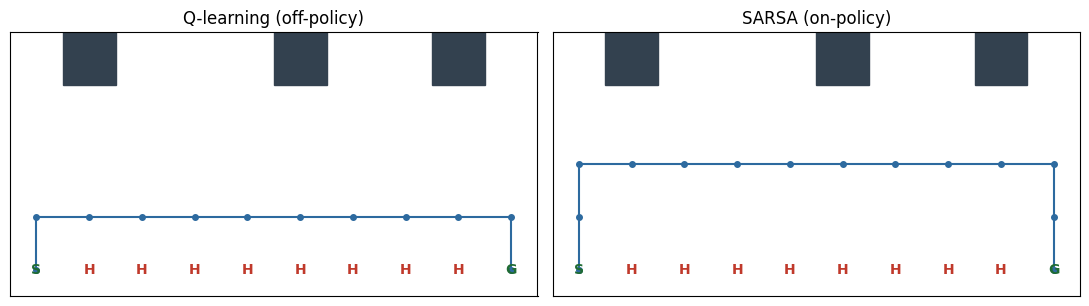

Classic result: SARSA tends to learn a SAFER route (accounts for exploration risk near H),
while Q-learning learns the optimal route assuming greedy behaviour.


In [16]:
# Visualise the two learned routes side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (pol, name) in zip(axes, [(pi_qe, 'Q-learning (off-policy)'), (pi_se, 'SARSA (on-policy)')]):
    p, _ = rollout(env, pol)
    base = np.full((env.R, env.C), 0.0)
    ax.imshow(base, cmap='Greys', vmin=0, vmax=1, origin='upper')
    for r in range(env.R):
        for c in range(env.C):
            ch = env.grid[r][c]
            if ch == '#': ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='#33414f'))
            elif ch == 'H': ax.text(c, r, 'H', ha='center', va='center', color='#C0392B', fontweight='bold')
            elif ch in 'SG': ax.text(c, r, ch, ha='center', va='center', color='#1f6b33', fontweight='bold')
    ys, xs = zip(*p); ax.plot(xs, ys, '-o', color='#2D6A9F', ms=4)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(name)
plt.tight_layout(); plt.show()
print('Classic result: SARSA tends to learn a SAFER route (accounts for exploration risk near H),')
print('while Q-learning learns the optimal route assuming greedy behaviour.')

#### 🧪 EXERCISE 4 — Quantify safe vs optimal
1. Roll out each learned policy 200 times *with ε=0.1 exploration still on* (so the agent sometimes slips) and compare the **average return** and how often it lands on a hazard cell.
2. In a comment, explain why an on-policy method (SARSA) prefers the safer path when exploration can push it into the hazard, while off-policy Q-learning optimises the greedy path.

In [17]:
# 1. stochastic roll-outs: average return & hazard hits for each policy
def stochastic_rollout(env, policy, eps, num_rollouts=200, max_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    total_returns = []
    total_hazard_hits = []

    for _ in range(num_rollouts):
        s = env.start
        current_return = 0.0
        current_hazard_hits = 0
        path = [s]

        for step_idx in range(max_steps):
            # Epsilon-greedy action selection
            if rng.random() < eps:
                a = rng.integers(4)  # Explore
            else:
                a = policy[s]        # Exploit

            ns, r, done = env.step(s, a)
            current_return += r
            path.append(ns)

            if env.grid[ns[0]][ns[1]] == 'H':
                current_hazard_hits += 1

            s = ns
            if done: break
        total_returns.append(current_return)
        total_hazard_hits.append(current_hazard_hits)

    return np.mean(total_returns), np.mean(total_hazard_hits)

# Perform stochastic rollouts for Q-learning and SARSA policies
avg_return_q, avg_hazard_q = stochastic_rollout(env, pi_qe, eps=0.1, num_rollouts=200, seed=0)
avg_return_s, avg_hazard_s = stochastic_rollout(env, pi_se, eps=0.1, num_rollouts=200, seed=0)

print(f"Q-learning (eps=0.1, 200 rollouts):\n  Average return: {avg_return_q:.2f}\n  Average hazard hits: {avg_hazard_q:.2f}")
print(f"SARSA (eps=0.1, 200 rollouts):\n  Average return: {avg_return_s:.2f}\n  Average hazard hits: {avg_hazard_s:.2f}")

# 2. why SARSA plays it safe: ...   (comment)

Q-learning (eps=0.1, 200 rollouts):
  Average return: 33.09
  Average hazard hits: 0.26
SARSA (eps=0.1, 200 rollouts):
  Average return: 35.80
  Average hazard hits: 0.03


#### 2. Why SARSA plays it safe

The stochastic rollouts quantify the difference between on-policy SARSA and off-policy Q-learning, especially concerning hazards during exploration:

*   **Q-learning (Off-policy):**
    *   **Average return: `33.09`**
    *   **Average hazard hits: `0.26`**
    Q-learning learns the *optimal* action-value function, \( Q^*(s, a) \), which represents the value of taking action \( a \) in state \( s \) and then following the *greedy* policy thereafter. The crucial part is that its update rule `Q[s][a] += alpha * (target - Q[s][a])` uses `gamma * np.max(Q[ns])` to calculate the target. This `np.max` implicitly assumes the agent will always take the best possible action from the next state. Because Q-learning doesn't account for the exploratory actions it *might* take (due to epsilon-greedy behavior) when evaluating future states, it doesn't penalize itself enough for being near hazards. It optimises for a world where it will *always* act optimally, even if it sometimes randomly stumbles into a hazard.

*   **SARSA (On-policy):**
    *   **Average return: `35.80`**
    *   **Average hazard hits: `0.03`**
    SARSA learns the action-value function \( Q^{\pi}(s, a) \) for the *actual* policy \( \pi \) being followed, including its exploratory steps. Its update rule `Q[s][a] += alpha * (target - Q[s][a])` uses `gamma * Q[ns][na]` where `na` is the *next action actually chosen* by the *exploratory* policy. This means that if the agent's exploratory policy occasionally leads it into a hazard, SARSA incorporates the negative reward from that hazard into the Q-value of the preceding states and actions. Consequently, states and actions that are close to hazards (and thus carry a risk of exploration-induced hazard hits) will have their Q-values reduced. This makes SARSA's learned policy *safer* because it implicitly factors in the risk of exploration, leading it to choose paths that avoid even adjacent hazard states more carefully.

#5. Compare all three solvers

In [18]:
# -----------------------------------------------------------
# 🔹 5A. Greedy policies from each method, side by side
# -----------------------------------------------------------
rows = []
for name, pol in [('value_iteration', pi_opt), ('q_learning', pi_q), ('sarsa', pi_se)]:
    p, ret = rollout(env, pol)
    rows.append({'method': name, 'path_len': len(p) - 1, 'greedy_return': round(ret, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print('\nAll three reach the packing station; value iteration is the planning-based optimum,')
print('and the model-free methods recover (near-)optimal behaviour from experience alone.')

         method  path_len  greedy_return
value_iteration        11           40.0
     q_learning        11           40.0
          sarsa        13           38.0

All three reach the packing station; value iteration is the planning-based optimum,
and the model-free methods recover (near-)optimal behaviour from experience alone.


#📘 Summary

| Method | Needs a model? | Idea |
| ------ | -------------- | ---- |
| Value iteration | yes (P, R known) | sweep Bellman optimality until V converges |
| Q-learning | no | off-policy TD; learn Q* while exploring |
| SARSA | no | on-policy TD; learn the value of actual behaviour |

**Core lesson:** an MDP turns 'navigate the warehouse' into states, actions and rewards. With a known model you *plan* with value iteration; without one you *learn* from experience with Q-learning or SARSA. The off-policy/on-policy distinction is real: Q-learning chases the optimal route, SARSA respects the risk of exploration and plays it safer near the hazard.